March 6, 2024

# D207: Exploratory Data Analysis | EDA Task 1

## Hannah R. Bergman
Student ID: 001539744 | WGU Email: [hbergm3@wgu.edu](mailto:hbergm3@wgu.edu)

---
Table of Contents:
- [Section A: Research Question](#a)
    - [A1. Research Question](#a1)
    - [A2. Organizational Benefits](#a2) 
    - [A3. Relevant Data](#a3)
- [Section B: Data Analysis](#b)
    - [B1. Variable Analysis, Chi-Square Test & Output](#b1)
    - [B2. Data Analysis Results](#b2)
    - [B3. Chi-Square Technique Justification](#b3)
- [Section C. Univariate Statistics | 2 Categorical & 2 Continuous Variables](#c)
    - [C1. Univariate Visualizations](#c1)
        - [Univariate Visualization #1](#uv1)
        - [Univariate Visualization #2](#uv2)
        - [Univariate Visualization #3](#uv3)
        - [Univariate Visualization #4](#uv4)
- [Section D. Bivariate Statistics | 2 Categorical & Continuous Variable Pairings](#d)
    - [D1. Bivariate Visualizations](#d1)
        - [Bivariate Visualization #1](#bv1)
        - [Bivariate Visualization #2](#bv2)
- [Section E: Summary](#e)
    - [E1. Results of the Hypothesis Test](#e1)
    - [E2. Limitations of the Data Analysis](#e2)
    - [E3. Recommendations](#e3)
 - [Section F: Panopto Video Recording](#f) 
 - [Section G: Data & Code Sources](#g)  
 - [Section H: References](#h) 
 ---

<a id="a"></a>
# Section A. Research Question

<a id="a1"></a>
## A1. Research Question

Is **high blood pressure** correlated with a patient being **overweight**? 

---
Being overweight elevates the risk of developing metabolic syndrome, characterized by risk factors like high blood pressure (John Hopkins Medicine, n.d.). Building on this existing medical research, which suggests a correlation between obesity and increased prevalence of high blood pressure, my study aims to investigate whether this association holds true within our own patient population. 

I hypothesize that overweight patients admitted to our hospital will exhibit a higher incidence of comorbidities commonly linked to obesity, such as high blood pressure and the goal of my research question is to provide targeted evidence to either support or refute this hypothesis.

To answer this question with high confidence (95%), we'll use a significance level of 0.05. This means we're willing to accept a 5% chance of mistakenly concluding that overweight status and high blood pressure are related when they actually are not.

<a id="a2"></a>
## A2. Organizational Benefits 

#### Informed Policy Development
- By providing valuable insights into the association between high blood pressure and obesity, our organization's policy makers can make strategic decisions regarding resource allocation and public health policy development. This can lead to **more efficient use of resources**, targeted interventions, and improved population health outcomes.

#### Optimized Patient Care Delivery
- Proactive intervention and personalized care can lead to early detection and management of high blood pressure and obesity, ultimately resulting in **lower overall healthcare costs for the organization**.

#### Enhanced Effectiveness of Preventative Programs
- Programs focused on both weight management and blood pressure control can help decrease the likelihood of our patients developing related chronic diseases such as heart disease, heart attack, and stroke (CDC, 2021), thereby **minimizing future healthcare burden on our organization**. 

<a id="a3"></a>
## A3. Relevant Data

### Variables Relevant To Our Research Question
- #### 'Overweight' / 'overweight'
    - Data Type: Qualitative (Boolean), Categorical (Dependent)
    - Description: This column represents a text representation of a boolean value ("Yes" or "No")
- #### 'HighBlood' / 'high_blood_pressure'
    - Data Type: Qualitative (Boolean), Categorical (Independent) 
    - Description: This column represents a boolean value (1 = True = “Yes” or 0 = False = “No”) indicating whether the patient is considered overweight based on the patient’s age, gender and height. 

### Data Preparation

In [1]:
# Import necessary libraries
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read in & preview the dataset 
df_medical = pd.read_csv('medical_clean.csv')
df_medical.head()

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,...,TotalCharge,Additional_charges,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,C412403,8cd49b13-f45a-4b47-a2bd-173ffa932c2f,3a83ddb66e2ae73798bdf1d705dc0932,Eva,AL,Morgan,35621,34.34960,-86.72508,...,3726.702860,17939.403420,3,3,2,2,4,3,3,4
1,2,Z919181,d2450b70-0337-4406-bdbb-bc1037f1734c,176354c5eef714957d486009feabf195,Marianna,FL,Jackson,32446,30.84513,-85.22907,...,4193.190458,17612.998120,3,4,3,4,4,4,3,3
2,3,F995323,a2057123-abf5-4a2c-abad-8ffe33512562,e19a0fa00aeda885b8a436757e889bc9,Sioux Falls,SD,Minnehaha,57110,43.54321,-96.63772,...,2434.234222,17505.192460,2,4,4,4,3,4,3,3
3,4,A879973,1dec528d-eb34-4079-adce-0d7a40e82205,cd17d7b6d152cb6f23957346d11c3f07,New Richland,MN,Waseca,56072,43.89744,-93.51479,...,2127.830423,12993.437350,3,5,5,3,4,5,5,5
4,5,C544523,5885f56b-d6da-43a3-8760-83583af94266,d2f0425877b10ed6bb381f3e2579424a,West Point,VA,King William,23181,37.59894,-76.88958,...,2113.073274,3716.525786,2,1,3,3,5,3,4,3


### Check For Missing Values

To identify any missing values, the isnull() method is applied to all columns. 

In [3]:
df_medical.isnull().sum()

CaseOrder             0
Customer_id           0
Interaction           0
UID                   0
City                  0
State                 0
County                0
Zip                   0
Lat                   0
Lng                   0
Population            0
Area                  0
TimeZone              0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charg

### Feature Selection 

Columns with high cardinality (many unique values) or those deemed irrelevant to the research question will be dropped using the drop() method.

In [4]:
# Drop columns with unique/serialized values
    ## Each of these columns contains 10,000 levels of cardinality (very high) due to the nature of the data
df_medical = df_medical.drop(columns=['CaseOrder', 'Customer_id', 'Interaction', 'UID'])

In [5]:
# These categorical variables have low cardinality with less than 5 levels in each 
    ## however the info is irrelevant to our research so we'll drop these
df_medical = df_medical.drop(columns=['Services', 'ReAdmis','Initial_admin'])

In [6]:
# These categorical variables have relatively low cardinality with less than 8 levels in each 
    ## however the info is still irrelevant to our research so we'll drop these as well
df_medical = df_medical.drop(columns=['Item1', 'Item2', 'Item3', 'Item4', 'Item5', 'Item6', 'Item7', 'Item8'])

In [7]:
# Drop other categoricals & continous variables with high cardinality
    ## These columns contain geographic demo info we don't need to answer our research question
df_medical = df_medical.drop(columns=['City', 'State', 'County', 'Population', 'Zip', 'Lat', 'Lng', 'TimeZone'])

In [8]:
# This additional information also does not pertain to our research question
df_medical = df_medical.drop(columns=['Job','Doc_visits','Full_meals_eaten','TotalCharge','Additional_charges','Initial_days'])

### Label Standardization

To improve data clarity and consistency, a new variable named updated_labels will be created. This variable will store an array of new column names that are standardized to lowercase, separated by underscores, and more accurately reflect the data they represent. 

In [9]:
# Define updated column labels, standardized for improved readability & more accurate to the data they reflect for better clarity
updated_labels = ["area_type", "children_in_household", "patient_age", "policyholder_income", "marital_status", 
                  "gender_identity", "vitamin_d_level", "vitamin_d_supplements", "habitual_soda_consumption", 
                  "high_blood_pressure", "stroke", "complication_risk_level", 
                  "overweight", "arthritis", "diabetes", "hyperlipidemia", "back_pain", "anxiety", 
                  "allergic_rhinitis", "reflux_esophagitis", "asthma"]

# Assign updated column labels to the dataframe
df_medical.columns = updated_labels

In [10]:
# Display the updated dataframe for review
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df_medical.head(100)

,area_type,children_in_household,patient_age,policyholder_income,marital_status,gender_identity,vitamin_d_level,vitamin_d_supplements,habitual_soda_consumption,high_blood_pressure,stroke,complication_risk_level,overweight,arthritis,diabetes,hyperlipidemia,back_pain,anxiety,allergic_rhinitis,reflux_esophagitis,asthma
0,Suburban,1,53,86575.93,Divorced,Male,19.141466,0,No,Yes,No,Medium,No,Yes,Yes,No,Yes,Yes,Yes,No,Yes
1,Urban,3,51,46805.99,Married,Female,18.940352,1,No,Yes,No,High,Yes,No,No,No,No,No,No,Yes,No
2,Suburban,3,53,14370.14,Widowed,Female,18.057507,0,No,Yes,No,Medium,Yes,No,Yes,No,No,No,No,No,No
3,Suburban,0,78,39741.49,Married,Male,16.576858,0,No,No,Yes,Medium,No,Yes,No,No,No,No,No,Yes,Yes
4,Rural,1,22,1209.56,Widowed,Female,17.439069,2,Yes,No,No,Low,No,No,No,Yes,No,No,Yes,No,No
5,Urban,3,76,81999.88,Never Married,Male,19.612646,0,No,No,No,Medium,Yes,Yes,Yes,No,Yes,No,Yes,No,No
6,Rural,0,50,10456.05,Never Married,Male,14.751687,0,No,Yes,No,Low,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,No
7,Urban,7,40,38319.29,Divorced,Female,19.688673,0,No,No,No,Medium,Yes,No,No,No,No,No,No,No,No
8,Urban,0,48,55586.48,Widowed,Male,19.653320,0,No,No,No,Low,Yes,No,No,Yes,No,No,No,No,No
9,Urban,2,78,38965.22,Never Married,Female,18.224324,2,No,Yes,No,High,Yes,No,No,No,No,No,Yes,Yes,Yes


<a id="b"></a>
# Section B. Data Analysis

<a id="b1"></a>
## B1. Variable Analysis, Chi-Square Test & Output

To analyze the relationship between being overweight and high blood pressure, we'll use a chi-square test. This statistical method is ideal for examining associations between categorical variables, like the ones we have here ('overweight' and 'high_blood_pressure'). By performing a chi-square test, we'll be able to determine if there's actually a statistically significant link between a patient being overweight and them having high blood presure. 

In [11]:
# CHI-SQUARE TEST

# Initialize a dictionary to store chi-square test results
chi_square_results = {}

# Create a contingency table for high blood pressure & overweight status
contingency_table = pd.crosstab(df_medical['high_blood_pressure'], df_medical['overweight'])

# Perform the chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Store the results in our dictionary 
chi_square_results['high_blood_pressure'] = {'Chi2': chi2, 'p-value': p}

# Convert the dictionary to a dataframe for improved readability
chi_square_results_df = pd.DataFrame(chi_square_results).T

# Display the dataframe
chi_square_results_df

,Chi2,p-value
high_blood_pressure,6.763426,0.009304


<a id="b2"></a>
## B2. Data Analysis Results

Our research question aimed to determine if there's a statistically significant link between being overweight and having high blood pressure. We set the significance level at 0.05, meaning we'd be 95% confident in rejecting the null hypothesis (no association) if the evidence suggests otherwise.

The data analysis revealed a strong association between these factors (p-value = 0.0009304). This value, well below our chosen significance level, indicates the observed link is highly unlikely to be due to chance. In other words, within this specific dataset, overweight individuals are significantly more likely to have high blood pressure.

To better understand the connection between being overweight and high blood pressure, let's look at a crosstab table:  

In [12]:
# Generate a crosstab table 
    ## Shows patients that are overweight/not overweight vs. patients with/without high blood pressure
highbp_x_overweight = pd.crosstab(df_medical['overweight'], df_medical['high_blood_pressure'], margins=True, margins_name="Total")

# Display the table
highbp_x_overweight

high_blood_pressure,No,Yes,Total
overweight,,,
No,1776,1130,2906
Yes,4134,2960,7094
Total,5910,4090,10000


This table reveals a clear pattern: overweight individuals are much more likely to experience high blood pressure compared to those with a healthy weight. This observation aligns perfectly with the statistical results from the chi-square test, further supporting the existence of a relationship between these two factors.

<a id="b3"></a>
## B3. Chi-Square Technique Justification

### Justification for Chi-Square Test Selection

For my research, a chi-square test was chosen over other methods for the following reasons:
- **Data Type & Suitability**
    - Chi-square tests are designed to analyze the association between categorical variables, examining if the observed distribution of the data aligns with expected distribution. In this study, the research question focused on the association between being overweight (a categorical “yes/no” variable) and the presence or absence of high blood pressure (also a categorical “yes/no” variable). Therefore, the chi-square test was directly applicable to the data structure. 
- **Comparison with Other Tests**
    - T-test: Typically used to compare the means of two groups (independent or paired samples) for continuous outcome variables. If the objective was to compare the average values of a continuous variable (for example, average income) between overweight and non-overweight patients (assuming normality), a t-test would have been more appropriate.
    - ANOVA (Analysis of Variance): Similar to t-tests, ANOVA assumes normally distributed, continuous data and compares means across 3 or more groups. Since all variables in this study are categorical, ANOVA was not suitable.
    
### Objective Alignment

The research question aimed to identify an association between overweight status (categorical) and high blood pressure (categorical). As both the independent and dependent variables are categorical in nature, the chi-square test presented itself as the most appropriate option. It allowed for testing the hypothesis that the occurrence of high blood pressure is independent of overweight status. 

In summary, the chi-square test was chosen for its suitability in analyzing categorical data and its ability to test for associations between two categorical variables, aligning perfectly with the objective of my research question. T-tests and ANOVA are excellent for comparing means but simply do not fit the nature of my data and my research question being focused on categorical outcomes. 

<a id="c"></a>
# Section C. Univariate Statistics

### Variables 
1. **patient_age** (Continuous)
2. **vitamin_d_level** (Continuous)
3. **complication_risk_level** (Categorical)
4. **marital_status** (Categorical)

In [13]:
# Perform univariate statistics for continuous variables: age and vitamin_d_level 
continuous_variable_stats = df_medical[['patient_age', 'vitamin_d_level']].describe()

# Display the results
continuous_variable_stats 

,patient_age,vitamin_d_level
count,10000.000000,10000.000000
mean,53.511700,17.964262
std,20.638538,2.017231
min,18.000000,9.806483
25%,36.000000,16.626439
50%,53.000000,17.951122
75%,71.000000,19.347963
max,89.000000,26.394449


In [14]:
# Perform univariate statistics for categorical variable: complication_risk_level
complication_risk_counts = df_medical['complication_risk_level'].value_counts()

# Display the results
complication_risk_counts

Medium    4517
High      3358
Low       2125
Name: complication_risk_level, dtype: int64

In [15]:
# Perform univariate statistics for categorical variable: marital_status
marital_counts = df_medical['marital_status'].value_counts()

# Display the results
marital_counts

Widowed          2045
Married          2023
Separated        1987
Never Married    1984
Divorced         1961
Name: marital_status, dtype: int64

<a id="c1"></a>
## C1. Univariate Visualizations

<a id="uv1"></a>
## Univariate Visualization #1

Univariate exploration of continuous 'patient_age' variable using histogram

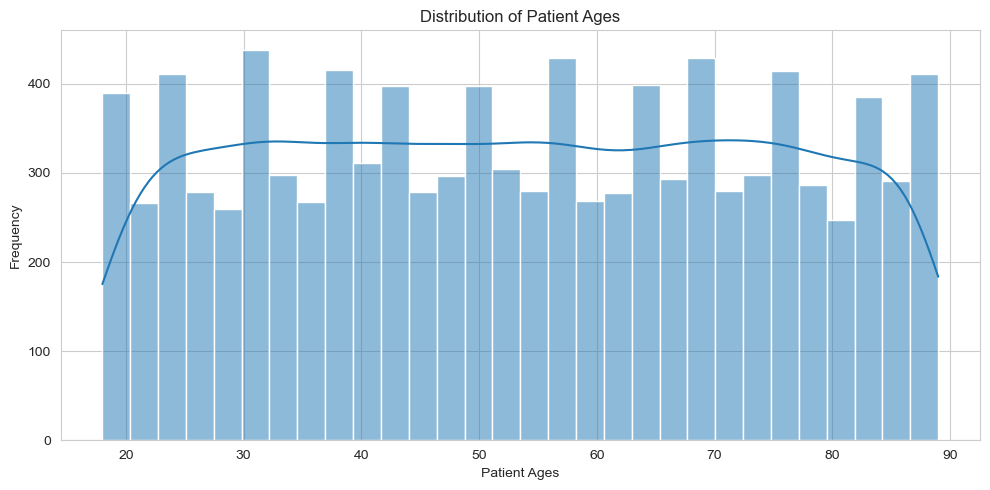

In [16]:
# Set the style of the plot to appear on a grid for easier readability
sns.set_style("whitegrid")

# Define the figure for plot
fig, ax = plt.subplots(figsize=(10, 5))

# Generate histogram for ages
sns.histplot(df_medical['patient_age'], bins=30, kde=True, ax=ax)
ax.set_title('Distribution of Patient Ages')
ax.set_xlabel('Patient Ages')
ax.set_ylabel('Frequency')
plt.tight_layout()

# Show plot
plt.show()

# Using a histogram displays the distribution of age among the patients in the dataset
# Includes a Kernel Density Estimate (KDE), the darker blue line, to show the data's distribution curve

### Univariate Stats 
1. **patient_age** (Continuous)
    - Count: 10,000 (total number of entries)
    - Mean: 53.51 years
    - Standard Deviation: 20.64 years
    - Minimum: 18 years
    - 25th Percentile: 36 years
    - Median (50th Percentile): 53 years
    - 75th Percentile: 71 years
    - Maximum: 89 years
    
### Interpretation 
The analysis reveals a diverse patient population with an average age of about 53 years, indicating a central tendency towards middle age. Despite this central point, the wide age range (18-89 years) and high standard deviation highlight the presence of both younger and older adults. This age distribution necessitates a multifaceted approach to healthcare, considering the distinct needs and priorities of different age groups, particularly the substantial portion approaching or within senior age brackets.

<a id="uv2"></a>
## Univariate Visualization #2

Univariate exploration of continuous 'vitamin_d_level' variable using histogram

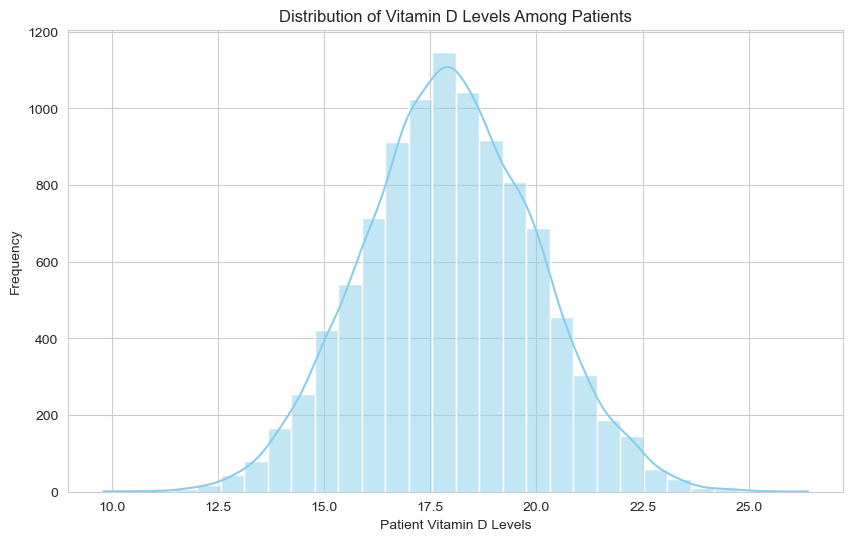

In [17]:
# Histogram for vitamin_d_level
plt.figure(figsize=(10, 6))
sns.histplot(df_medical['vitamin_d_level'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Vitamin D Levels Among Patients')
plt.xlabel('Patient Vitamin D Levels')
plt.ylabel('Frequency')

# Show plot
plt.show()

# This histogram visualizes the distribution of vitamin D levels among the patients 
# The darker blue line, kernel density estimate (KDE), depicts the underlying continuous distribution of the data

### Univariate Stats
2. **vitamin_d_level** (Continuous)
    - Count: 10,000
    - Mean: 17.96 ng/mL
    - Standard Deviation: 2.02 ng/mL
    - Minimum: 9.81 ng/mL
    - 25th Percentile: 16.63 ng/mL
    - Median (50th Percentile): 17.95 ng/mL
    - 75th Percentile: 19.35 ng/mL
    - Maximum: 26.39 ng/mL
    
### Interpretation 
The vitamin D levels follow a normal distribution (notable by the bell-shaped curve), with most patients falling within a moderate and relatively homogenous range around the average. The absence of skewness and outliers suggests that extreme values are uncommon, providing valuable insights for establishing reference ranges and identifying potentially concerning levels.

<a id="uv3"></a>
## Univariate Visualization #3

Univariate exploration of categorical 'marital_status' status variable using pie chart

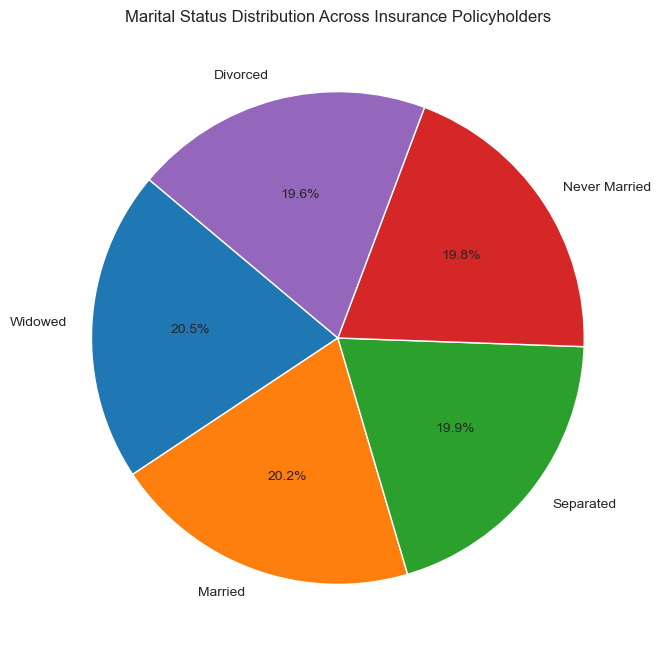

In [18]:
# Generate pie chart 
marital_counts = df_medical['marital_status'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(marital_counts, labels=marital_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Marital Status Distribution Across Insurance Policyholders')

# Show plot
plt.show()

# This pie chart breaks down the distribution of marital statuses within the dataset 
# Each slice of the pie represents a specific marital category
# with its size reflecting the corresponding percentage (%) of patients within that category

### Univariate Stats 
4. **marital_status** (Categorical)
    - Widowed: 2,045 policyholders/patients
    - Married: 2,023 policyholders/patients
    - Separated: 1,987 policyholders/patients
    - Never Married: 1,984 policyholders/patients
    - Divorced: 1,961 policyholders/patients
    
### Interpretation
The analysis of marital status reveals a diverse population with nearly equal representation across all categories. "Married" and "Widowed" are the most prevalent at over 20% each, followed closely by "Never Married," "Divorced," and "Separated." This balanced distribution highlights the need for considering marital status when designing policies and services to cater to the varied needs of the policyholder population

<a id="uv4"></a>
## Univariate Visualization #4

Univariate exploration of categorical 'complication_risk_level' status variable using bar chart

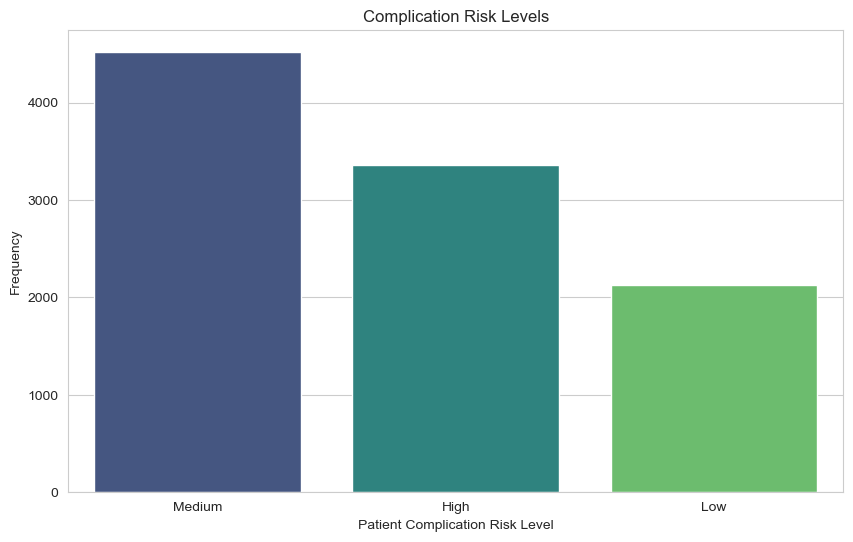

In [19]:
# Generate bar chart for complication_risk_level
complication_risk_counts = df_medical['complication_risk_level'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=complication_risk_counts.index, y=complication_risk_counts.values, palette='viridis')
plt.title('Complication Risk Levels')
plt.xlabel('Patient Complication Risk Level')
plt.ylabel('Frequency')

# Show plot
plt.show()

# A bar chart effectively displays the frequency of each complication risk level ('Low', 'Medium', and 'High') 
# allowing for a clear comparison of their prevalence

### Univariate Stats 
3. **complication_risk_level** (Categorical)
    - Medium: 4,517 patients
    - High: 3,358 patients
    - Low: 2,125 patients

### Interpretation 
The analysis reveals an uneven distribution of complication risk levels. The majority of patients fall under the "Medium" risk category, followed by "High" and then "Low" risk. This suggests a need for tailored approaches to patient care, with potentially higher resource allocation and more intensive monitoring for the "High" risk group. Understanding this distribution is crucial for effective resource management, care planning, and risk mitigation strategies within our healthcare system.

<a id="d"></a>
# Section D. Bivariate Statistics

### Variable Pairs 
1. **gender_identity** (Categorical) vs. **policyholder_income** (Continuous)  
2. **area_type** (Categorical) vs. **children_in_household** (Continuous)

In [20]:
# Perform bivariate statistics for gender_identity vs. policyholder_income
gender_income_stats = df_medical.groupby('gender_identity')['policyholder_income'].agg(['mean', 'median', 'std'])

# Display the results
gender_income_stats 

,mean,median,std
gender_identity,,,
Female,40396.425606,33781.190,28144.090026
Male,40573.096898,33910.115,28771.099841
Nonbinary,40855.896729,30911.120,31676.123844


In [21]:
# Perform bivariate statistics for area_type vs. children_in_household
area_children_stats = df_medical.groupby('area_type')['children_in_household'].agg(['mean', 'median', 'std'])

# Display the results
area_children_stats

,mean,median,std
area_type,,,
Rural,2.077174,1.0,2.126209
Suburban,2.159856,2.0,2.214725
Urban,2.054496,1.0,2.148640


<a id="d1"></a>
## D1. Bivariate Visualizations

<a id="bv1"></a>
## Bivariate Visualization #1

Bivariate exploration of gender identity (categorical) vs. policyholder income (continuous)

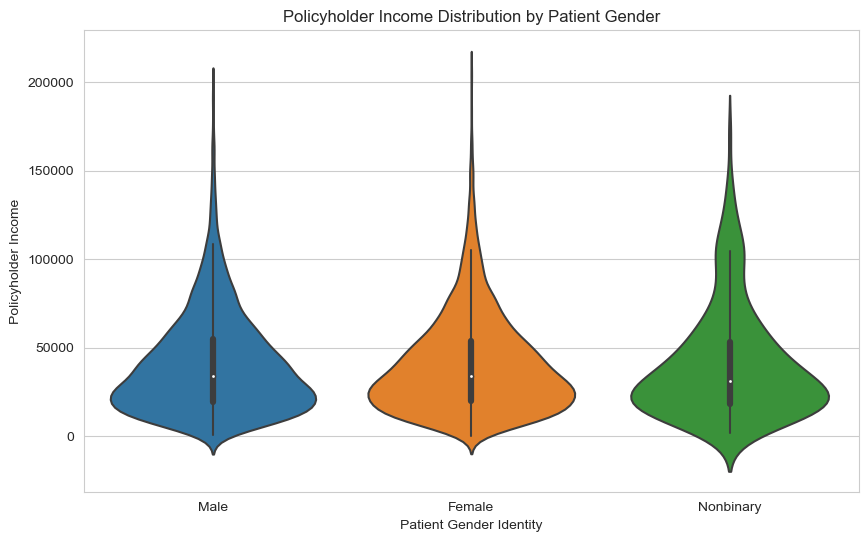

In [22]:
# Generate violin plot for gender identity vs. policyholder income
plt.figure(figsize=(10, 6))
sns.violinplot(x='gender_identity', y='policyholder_income', data=df_medical)
plt.title('Policyholder Income Distribution by Patient Gender')
plt.xlabel('Patient Gender Identity')
plt.ylabel('Policyholder Income')

# Show plot
plt.show()

### Bivariate Stats - Patient Gender vs. Policyholder Income Distribution 
1. **gender_identity** (Categorical) vs. **policyholder_income** (Continuous)  
- Female
    - Mean Income: 40,396.43 USD
    - Median Income: 33,781.19 USD
    - Standard Deviation: 28,144.09 USD
- Male
    - Mean Income: 40,573.10 USD
    - Median Income: 33,910.12 USD
    - Standard Deviation: 28,771.10 USD
- Nonbinary
    - Mean Income: 40,855.90 USD
    - Median Income: 30,911.12 USD
    - Standard Deviation: 31,676.12 USD

### Interpretation
Despite similar average incomes across all genders, deeper analysis reveals some disparities. Differences in median incomes and income spread suggest lower earnings and greater economic vulnerability for nonbinary individuals. 

<a id="bv2"></a>
## Bivariate Visualization #2

Bivariate exploration of area type (categorical) vs. number of children in patient's household (continuous)

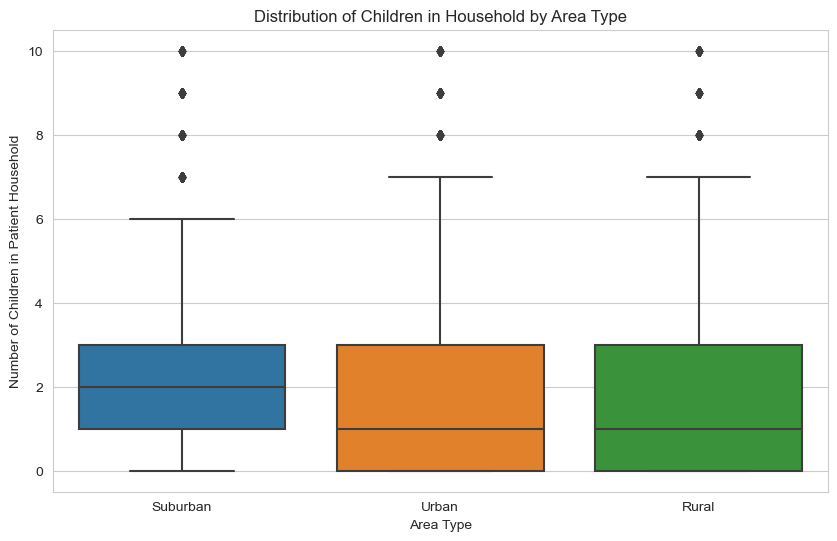

In [23]:
# Generate box plot for area vs. children
plt.figure(figsize=(10, 6))
sns.boxplot(x='area_type', y='children_in_household', data=df_medical)
plt.title('Distribution of Children in Household by Area Type')
plt.xlabel('Area Type')
plt.ylabel('Number of Children in Patient Household')

# Show plot
plt.show()

### Bivariate Stats - Area Type vs. Children in Household Distribution 
2. **area_type** (Categorical) vs. **children_in_household** (Continuous)
- Rural
    - Mean Children: 2.08
    - Median Children: 1.00
    - Standard Deviation: 2.13
- Suburban
    - Mean Children: 2.16
    - Median Children: 2.00
    - Standard Deviation: 2.21
- Urban
    - Mean Children: 2.05
    - Median Children: 1.00
    - Standard Deviation: 2.15
    
### Interpretation

Family size varies slightly across different areas. Suburban households tend to be larger, while urban households are smaller on average. Rural areas have a similar range of family sizes to urban areas, but with a slightly higher average. These differences likely reflect factors like housing availability, lifestyle choices, and socio-economic conditions in each type of area.

<a id="e"></a>
# Section E. Summary

<a id="e1"></a>
## E1. Results of the Hypothesis Test

This study investigated the potential link between being overweight and high blood pressure. Our analysis revealed a statistically significant association between being overweight and high blood pressure (p-value = 0.009304). This means that in our dataset, individuals who were overweight were more likely to have high blood pressure compared to those who were not overweight.

In conclusion, this study found a positive association between being overweight and high blood pressure within the analyzed data.

<a id="e2"></a>
## E2. Limitations of the Data Analysis
#### Sample Size
This analysis is based on a dataset containing only 10,000 patient records. While this may seem like a large number, it represents a relatively small sample size within the context of a nationwide hospital network. A larger and more diverse sample encompassing various geographic regions and more patient demographics would likely yield more robust results and allow for a more comprehensive understanding of the relationship between overweight status and high blood pressure.

#### Oversimplification of ‘Overweight’ Category
The analysis relies on a binary classification of patients as either ‘overweight’ or not overweight. This approach lacks the necessary granularity for more nuanced analysis. The variable doesn’t distinguish individuals who are mildly overweight versus those who might actually be morbidly obese. This lack of differentiation could lead to misleading interpretations and an underestimation of the potential health risks associated with varying degrees of excess weight. For instance, the health risks and implications of being just 2 pounds overweight are vastly different from someone carrying 200+ pounds of excess weight. Lumping them together undermines the severity of one and minimizes the potential dangers of the other.

<a id="e3"></a>
## E3. Recommendations
By collaborating with data analysts and healthcare professionals, we can refine our data collection methods and ensure that the information we collect is accurate, comprehensive, and standardized. This will empower us to leverage the full potential of data analytics and transform healthcare for the better. By analyzing data trends, we can identify patterns and risk factors associated with various conditions, such as high blood pressure and obesity. This knowledge can inform personalized care plans, preventative strategies, and targeted interventions within our patient population. 

Our research identified a link between being overweight and high blood pressure. This finding can be used to develop educational programs for patients, highlighting the associated risks of high blood pressure, such as heart attack, stroke, and kidney complications (World Health Organization, 2023).This can help us help our patients make informed decisions and take proactive steps towards better health


<a id="f"></a>
# Section F. Panopto Video Recording
Panopto video recording: [https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=f710a7f5-d2c8-4cca-ae4d-b12c01428f9b](https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=f710a7f5-d2c8-4cca-ae4d-b12c01428f9b)

<a id="g"></a>
# Section G. Data & Code Sources
- Western Governors University. (2023). *Medical Data and Dictionary Files* [Dataset]. Data Files and Associated Dictionary Files.
    - Retrieved February 28, 2024, from
	- [https://access.wgu.edu/ASP3/aap/content/g9rke9s0rlc9ejd92md0.html](https://access.wgu.edu/ASP3/aap/content/g9rke9s0rlc9ejd92md0.html) 

<a id="h"></a>
# Section H. References
- American Lung Association (2022, December 7). *Types of Asthma.* Learn About Asthma.
    - Retrieved March 2, 2024, from
    - [lung.org/lung-health-diseases/lung-disease-lookup/asthma/learn-about-asthma/types](lung.org/lung-health-diseases/lung-disease-lookup/asthma/learn-about-asthma/types)
- Centers for Disease Control and Prevention (2021, May 18). *High Blood Pressure Symptoms & Causes.*
    - Retrieved March 4, 2024, from
	- [https://www.cdc.gov/bloodpressure/about.html](https://www.cdc.gov/bloodpressure/about.html) 
- Centers for Disease Control and Prevention (2022, December). *Mortality in the United States, 2021.* NCHS Data Brief No. 456.
    - Retrieved February 28, 2024, from
	- [https://www.cdc.gov/diabetes/basics/index.html](https://www.cdc.gov/diabetes/basics/index.html) 
- Centers for Disease Control and Prevention (2023, September 5). *Diabetes Basics.*
    - Retrieved February 28, 2024, from
	- [https://www.cdc.gov/diabetes/basics/index.html](https://www.cdc.gov/diabetes/basics/index.html) 
- Dixon, A. E. & Nyenhuis, S. M. (2022, May 17). *Obesity and asthma.* UpToDate.
    - Retrieved February 28, 2024, from 
	- [https://www.uptodate.com/contents/obesity-and-asthma](https://www.uptodate.com/contents/obesity-and-asthma) 
- Johns Hopkins Medicine (n.d.). *Metabolic Syndrome.*
    - Retrieved February 28, 2024, from
	- [https://www.hopkinsmedicine.org/health/conditions-and-diseases/metabolic-syndrome](https://www.hopkinsmedicine.org/health/conditions-and-diseases/metabolic-syndrome)  
- Whelan, C. (2023, May 25). *Can Obesity Cause Back Pain?* Healthline.
    - Retrieved February 28, 2024, 2024, from 
	- [https://www.healthline.com/health/obesity/back-pain-and-obesity](https://www.healthline.com/health/obesity/back-pain-and-obesity) 
- Weir, C.B. & Jan, A. (2023, June 26). *BMI Classification Percentile and Cut Off Points.* National Library of Medicine.
    - Retrieved March 3, 2024, 2024, from 
	- [https://www.ncbi.nlm.nih.gov/books/NBK541070/](https://www.ncbi.nlm.nih.gov/books/NBK541070/) 
- World Health Organization.  (2023, March 16). *Hypertension.* Healthline.
    - Retrieved March 1, 2024, from 
	- [https://www.who.int/news-room/fact-sheets/detail/hypertension](https://www.who.int/news-room/fact-sheets/detail/hypertension)